In [1]:
!curl -I https://www.google.com


HTTP/2 200 
content-type: text/html; charset=ISO-8859-1
content-security-policy-report-only: object-src 'none';base-uri 'self';script-src 'nonce-05APyHThff-ilY6abvJ9Zw' 'strict-dynamic' 'report-sample' 'unsafe-eval' 'unsafe-inline' https: http:;report-uri https://csp.withgoogle.com/csp/gws/other-hp
accept-ch: Sec-CH-Prefers-Color-Scheme
p3p: CP="This is not a P3P policy! See g.co/p3phelp for more info."
date: Sun, 06 Sep 2026 16:45:28 GMT
server: gws
x-xss-protection: 0
x-frame-options: SAMEORIGIN
expires: Sun, 06 Sep 2026 16:45:28 GMT
cache-control: private
set-cookie: __Secure-STRP=ANmZwa2vAAb32kUI3NSaj6tQPZYA_y_gb7eHDRMdQv-4Y4-lEm3tOHhZBM1o2gz5Etc2MbzJHsQSo0NP1cXw1lwpJUfZ7n8sdWKR; expires=Sun, 06-Sep-2026 16:50:28 GMT; path=/; domain=.google.com; Secure; SameSite=strict
set-cookie: AEC=AdJVEasyy3fo_Cyc9dKsluD9o-c1WDbJr1BY6fVumf438_W9ySrqSsLiFQ; expires=Fri, 05-Mar-2027 16:45:28 GMT; path=/; domain=.google.com; Secure; HttpOnly; SameSite=lax
set-cookie: NID=534=T6JM6QsWAPUNKkLQrR6qQP

In [2]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 651.6 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 6.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 4.2 MB/s eta 0:00:00


In [3]:
# If running on Colab, uncomment the next line to install ultralytics
# !pip install ultralytics -q

import ultralytics
from ultralytics import YOLO
import os, shutil, glob, random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd

ultralytics.checks()

Ultralytics 8.4.142 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Setup complete ✅ (4 CPUs, 31.3 GB RAM, 7035.6/8062.4 GB disk)


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gabrielfcarvalho/cardd-with-yolo-annotations-images-labels")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/gabrielfcarvalho/cardd-with-yolo-annotations-images-labels


In [5]:
DATASET_ROOT = '/kaggle/input/datasets/gabrielfcarvalho/cardd-with-yolo-annotations-images-labels'  # <-- edit if on Colab

print(os.listdir(DATASET_ROOT))

['data.yaml', 'val', 'test', 'train']


In [6]:
data_yaml_content = f"""
train: {DATASET_ROOT}/train/images
val: {DATASET_ROOT}/val/images
test: {DATASET_ROOT}/test/images

nc: 6
names: ['dent', 'scratch', 'crack', 'glass shatter', 'lamp broken', 'tire flat']
"""

DATA_YAML_PATH = 'data.yaml'
with open(DATA_YAML_PATH, 'w') as f:
    f.write(data_yaml_content)

print(data_yaml_content)


train: /kaggle/input/datasets/gabrielfcarvalho/cardd-with-yolo-annotations-images-labels/train/images
val: /kaggle/input/datasets/gabrielfcarvalho/cardd-with-yolo-annotations-images-labels/val/images
test: /kaggle/input/datasets/gabrielfcarvalho/cardd-with-yolo-annotations-images-labels/test/images

nc: 6
names: ['dent', 'scratch', 'crack', 'glass shatter', 'lamp broken', 'tire flat']



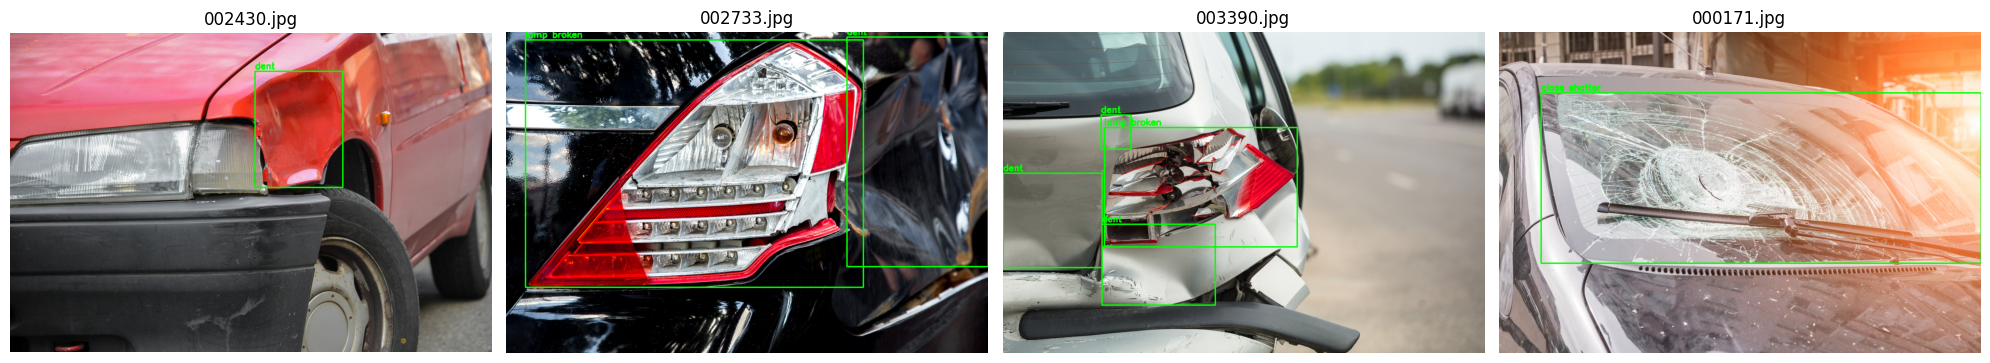

In [7]:
import cv2

CLASS_NAMES = ['dent', 'scratch', 'crack', 'glass shatter', 'lamp broken', 'tire flat']

train_img_dir = f'{DATASET_ROOT}/train/images'
train_lbl_dir = f'{DATASET_ROOT}/train/labels'

sample_imgs = random.sample(os.listdir(train_img_dir), 4)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, img_name in zip(axes, sample_imgs):
    img_path = os.path.join(train_img_dir, img_name)
    lbl_path = os.path.join(train_lbl_dir, os.path.splitext(img_name)[0] + '.txt')

    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            for line in f.readlines():
                cls, xc, yc, bw, bh = map(float, line.split())
                x1 = int((xc - bw/2) * w)
                y1 = int((yc - bh/2) * h)
                x2 = int((xc + bw/2) * w)
                y2 = int((yc + bh/2) * h)
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(img, CLASS_NAMES[int(cls)], (x1, max(y1-5,0)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.axis('off')
    ax.set_title(img_name)

plt.tight_layout()
plt.show()

In [8]:
model = YOLO('yolov8s.pt')  # start from pretrained COCO weights, fine-tune on top

results = model.train(
    data=DATA_YAML_PATH,
    epochs=60,
    imgsz=640,
    batch=16,
    patience=15,
    project='car_damage_runs',
    name='yolov8s_cardd_finetune',
    exist_ok=True,
    plots=True
)

Ultralytics 8.4.142 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_cardd_finetune, nbs=64, nms=None, opset=None, optimize=False

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


       2/60      4.68G      1.498       2.17      1.636         73        640: 100% ━━━━━━━━━━━━ 176/176 4.6it/s 38.1s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 26/26 3.6it/s 7.2s0.3s
                   all        810       1744      0.685      0.286      0.365      0.237

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/60      4.69G       1.55      2.188      1.682         65        640: 100% ━━━━━━━━━━━━ 176/176 4.5it/s 39.3s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 26/26 3.6it/s 7.1s0.3s
                   all        810       1744      0.502      0.461      0.451      0.297

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       4/60      4.69G      1.513      2.107      1.661         50        640: 100% ━━━━━━━━━━━━ 176/176 4.5it/s 39.1s0.2ss
                 Class     Ima

In [11]:
import os

print(os.listdir("/kaggle/working"))

['.virtual_documents', 'weights', 'data.yaml', 'yolov8s.pt', 'runs']


In [12]:
!ls -lh /kaggle/working/runs/detect/car_damage_runs/yolov8s_cardd_finetune/weights/

total 43M
-rw-r--r-- 1 root root 22M Sep  6 17:34 best.pt
-rw-r--r-- 1 root root 22M Sep  6 17:34 last.pt


In [14]:
import shutil

shutil.copy(
    "/kaggle/working/runs/detect/car_damage_runs/yolov8s_cardd_finetune/weights/best.pt",
    "/kaggle/working/car_damage_best.pt"
)

shutil.copy(
    "/kaggle/working/runs/detect/car_damage_runs/yolov8s_cardd_finetune/weights/last.pt",
    "/kaggle/working/car_damage_last.pt"
)

'/kaggle/working/car_damage_last.pt'